# This notebook shows how to compute the Fermi surface a tunnel junction actually sees
### Import the necessary libraries


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from ase import Atoms
from ase.io import read
from elkpy.structure import Structure

B = 1 / 0.529177210903        # Bohr per Angstrom


### The Fermi surface is not what tunnels
A Bloch state's tail in the vacuum falls off with its own in-plane momentum,
$$ \psi \sim e^{-\kappa z}, \qquad \kappa = \sqrt{2(V_0-E) + |\mathbf{k}_\parallel + \mathbf{G}|^2} $$
so a Fermi-surface sheet far from the zone centre is exponentially invisible to a junction while one at $\Gamma$ is not.


### A planar tip makes the transmission momentum-resolved
Notebook 20's tip is a *point*, giving a map in real space. Make it an infinite plane and the same Landauer trace becomes a double plane integral, with the lateral momentum now conserved going in as well as out:
$$ T(E) = \int_{\rm tip}\!d^2r \int_{\rm exit}\!d^2r'\,|G(\mathbf{r},\mathbf{r}';E)|^2 = \sum_{\mathbf{k}} w_{\mathbf{k}}\,W(\mathbf{k};E), \qquad W(\mathbf{k};E) = \mathrm{Tr}\big[D\,G^{\rm t}_{\mathbf{k}}\,D\,S_{\mathbf{k}}\big] $$
with $D = \mathrm{diag}\sqrt{\delta_\eta(E-\varepsilon_{n\mathbf{k}})}$ the on-shell amplitudes and $G^{\rm t}, S$ the bands' Gram matrices on the tip and substrate planes. Setting both Gram matrices to the identity gives back $\sum_n \delta_\eta(E-\varepsilon_{n\mathbf{k}})$: the plain Fermi surface.


### Monolayer 1H-NbSe$_2$
One half-filled Nb $4d$ band crosses $E_F$, giving a hole pocket at $\Gamma$ and one at each of K and K$'$. The $\Gamma$ pocket is $d_{z^2}$ and points out of the plane; the K pockets are in-plane $d_{xy}, d_{x^2-y^2}$ at $|\mathbf{k}| = 4\pi/3a$.


In [2]:
C = 18.0                                 # cell height, ~14.6 A of vacuum
bulk = read("nbse2_cod_1539310.cif")     # COD 1539310, the bulk 2H refinement
a, c = bulk.cell.cellpar()[0], bulk.cell.cellpar()[2]
frac, sym = bulk.get_scaled_positions(), bulk.get_chemical_symbols()
# one layer: the Nb at z = 1/4 and the two Se sharing its (1/3, 2/3) column.
# Both Se on the SAME column is a trigonal prism, which is 1H; two different
# columns would be 1T -- a different material entirely
keep = [i for i in range(len(sym)) if abs(frac[i][2] - 0.25) < 0.2
        and (sym[i] == "Nb" or abs(frac[i][0] - 1/3) < 0.1)]
cell = bulk.cell.array.copy(); cell[2] = [0, 0, C]
layer = Atoms(symbols=[sym[i] for i in keep], cell=cell, pbc=True,
              positions=[frac[i][0]*cell[0] + frac[i][1]*cell[1]
                         + [0, 0, C/2 + (frac[i][2] - 0.25)*c] for i in keep])

calc = Structure.from_ase(layer).get_calculation(
    "_scratch/nbse2", xc="PBE", ngridk=(12, 12, 1), rgkmax=7.0,
    # spinpol stays False: DFT sits on a Stoner instability here and a
    # spurious ~1 mu_B moment would destroy the Fermi surface we are after
    # tshift: mandatory, or Elk moves the origin while the planes stay here
    extra_blocks={"tshift": [False], "swidth": [0.001], "maxscl": [100]})
calc.get_energy()


-8681.0278331753

### First the tip height, because `rgkmax` sets a floor
The Gram matrices come from Elk's interstitial plane-wave sum, whose reach into the vacuum is finite. The **large-$|\mathbf{k}|$ pocket runs out of basis first** -- the very pocket whose suppression is the answer -- so a contrast read off at one height cannot be told apart from numerical noise.


In [3]:
Z_TOP, Z_BOT = 0.5 + 1.680/C, 0.5 - 1.680/C     # the two Se planes
sweep = {}
for d in (1.5, 2.5, 3.5, 4.5, 5.5, 6.5):        # A above the outer Se
    # exit_region='cell' weights by the tip plane alone, so the slope
    # measured below is one kappa rather than two
    r = calc.get_tunnelling_fermi_surface(
        tip_height=Z_TOP + d/C, exit_height=Z_BOT - 4.0/C,
        kgrid=(12, 12, 1), broadening=0.004, exit_region="cell")
    k = r["kpoints"]
    ig = np.argmin(np.linalg.norm(k, axis=1))            # Gamma
    ik = np.argmin(np.linalg.norm(k - [1/3, 1/3, 0], axis=1))   # K
    sweep[d] = (r["weight"][0][ig], r["weight"][0][ik])


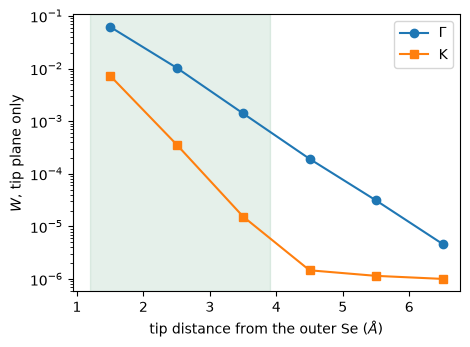

In [4]:
d = np.array(list(sweep))
g, kk = np.array([sweep[x][0] for x in d]), np.array([sweep[x][1] for x in d])
fig, ax = plt.subplots(figsize=(5, 3.6))
ax.semilogy(d, g, "o-", label="$\\Gamma$")
ax.semilogy(d, kk, "s-", label="K")
ax.axvspan(1.2, 3.9, color="seagreen", alpha=0.12)   # both still exponential
ax.set_xlabel("tip distance from the outer Se ($\\AA$)")
ax.set_ylabel("$W$, tip plane only"); ax.legend(); plt.show()


K is a straight line only out to about 3.5 $\AA$ and then flattens onto the basis floor -- flattens *height-independently*, which no bound state can do -- after which the *apparent* contrast falls again. Everything below is taken at 3.5 $\AA$, the last height at which both pockets are still exponential.


### The two Fermi surfaces
One run gives both: `"weight"` is $W(\mathbf{k};E_F)$ and `"bare"` is $\sum_n\delta_\eta(E_F-\varepsilon_{n\mathbf{k}})$ on the same mesh and the same eigenvalues.


In [5]:
# the mesh is generated by the task, so it is independent of ngridk and of
# reducek -- a symmetry-reduced mesh cannot draw a Fermi surface. 54 is a
# multiple of 3, so K is on it
D = 3.5
fs = calc.get_tunnelling_fermi_surface(
    tip_height=Z_TOP + D/C, exit_height=Z_BOT - D/C,
    kgrid=(54, 54, 1), broadening=0.003)


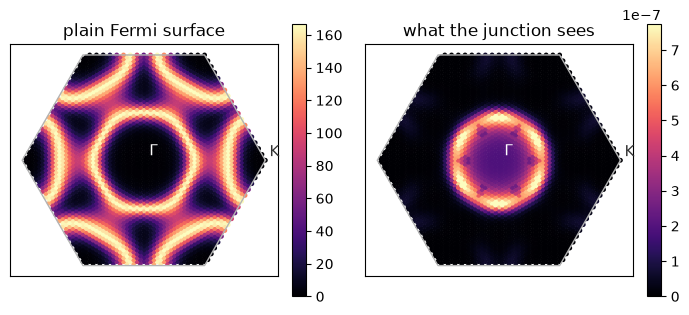

In [6]:
bvec = 2 * np.pi * np.linalg.inv(np.array(calc.structure.avec)).T
G = np.array([n1*bvec[0] + n2*bvec[1] for n1 in (-1,0,1) for n2 in (-1,0,1)])
cand = fs["kpoints_cartesian"][:, None, :] + G[None]      # fold into the 1st BZ
kf = cand[np.arange(len(cand)), np.argmin(np.linalg.norm(cand, axis=2), axis=1)] * B
# K sits at 0, 60, 120 ... degrees and M at 30, 90 ...: the reciprocal lattice
# is rotated 30 deg from the real one, so a hexagon drawn with corners at
# 30 deg would put the K label on an M point
corner = np.deg2rad(np.arange(0, 361, 60))

fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.0))
for ax, v, t in ((axes[0], fs["bare"][0], "plain Fermi surface"),
                 (axes[1], fs["weight"][0], "what the junction sees")):
    # linear, and every k-point: on this scale K is not dimmer than the Gamma
    # ring, it is zero. Masking low-weight points instead would leave the
    # inside of the Gamma hole pocket blank rather than dark
    s = ax.scatter(kf[:, 0], kf[:, 1], c=v, s=6, cmap="magma",
                   vmin=0, vmax=np.percentile(v, 99))
    kmag = 4*np.pi / (3*a)
    ax.plot(kmag*np.cos(corner), kmag*np.sin(corner), "-", color="0.7", lw=1)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.annotate("$\\Gamma$", (0, 0), color="w", fontsize=11,
                xytext=(4, 3), textcoords="offset points")
    ax.annotate("K", (kmag, 0), color="0.2", fontsize=11,
                xytext=(3, 3), textcoords="offset points")
    ax.set_title(t); fig.colorbar(s, ax=ax, fraction=.046)
plt.show()


### The junction's own transfer function
Their ratio has the density of states divided out, leaving only what the vacuum does: $W/\text{plain} \sim e^{-2\kappa(z_{\rm t}+z_{\rm e})}$, a function of $|\mathbf{k}|$ alone up to the states' orbital character.


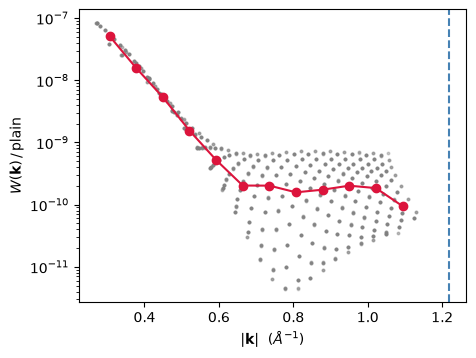

In [7]:
on_fs = fs["bare"][0] > 0.02 * fs["bare"][0].max()   # keep the real crossings
kmag = np.linalg.norm(kf, axis=1)[on_fs]
ratio = fs["weight"][0][on_fs] / fs["bare"][0][on_fs]
edges = np.linspace(kmag.min(), kmag.max(), 13)
mid = 0.5 * (edges[1:] + edges[:-1])
med = [np.median(ratio[(kmag >= u) & (kmag < v)]) for u, v in zip(edges[:-1], edges[1:])]

fig, ax = plt.subplots(figsize=(5, 3.8))
ax.scatter(kmag, ratio, s=3, alpha=.15, color="0.5")
ax.plot(mid, med, "o-", color="crimson")
ax.axvline(4*np.pi/(3*a), ls="--", color="steelblue")   # |K|
ax.set_yscale("log"); ax.set_xlabel("$|\\mathbf{k}|$  ($\\AA^{-1}$)")
ax.set_ylabel("$W(\\mathbf{k})\\,/\\,$plain"); plt.show()


### How much of the current each pocket carries
The K pockets hold most of the Fermi-level density of states and almost none of the tunnelling signal.


In [8]:
corners = np.array([(1/3,1/3,0), (-1/3,-1/3,0), (2/3,-1/3,0),
                    (-2/3,1/3,0), (1/3,-2/3,0), (-1/3,2/3,0)]) @ bvec * B
dK = np.min(np.linalg.norm(kf[:, None] - corners[None], axis=2), axis=1)
near_K = dK < np.linalg.norm(kf, axis=1)   # closer to a corner than to Gamma
for name, v in (("plain", fs["bare"][0]), ("tunnelling", fs["weight"][0])):
    share = v[near_K].sum() / v.sum()
    print(f"{name:11s}  K pockets carry {100*share:5.1f}% of the signal")


plain        K pockets carry  69.8% of the signal
tunnelling   K pockets carry   8.4% of the signal
